# SegTHOR vs TotalSegmentator

We pretrain on TotalSegmentator and fine-tune on SegTHOR, so it is worth knowing how the two differ.
Three sets of scans are compared here:

- **SegTHOR**, the dataset we ultimately care about;
- **TotalSegmentator**, as `prepare_totalseg.py` writes it: cropped to the thorax and clipped at -1000 HU;
- **TotalSegmentator original**, the very same subjects straight from the downloaded dataset, to see what
  the preprocessing took away.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import tqdm

SEGTHOR = Path("data/segthor_part1/train")
TOTALSEG = Path("data/totalseg_part1/train")
TOTALSEG_ORIGINAL = Path("data/Totalsegmentator_dataset_small_v201")
CACHE = Path("results/dataset_stats.pkl")  # delete this file to recompute

ORGANS = ["esophagus", "heart", "trachea", "aorta"]  # in label order, 1 to 4
BINS = np.arange(-3100, 4100, 20)  # HU bins for the intensity histograms
CENTERS = (BINS[:-1] + BINS[1:]) / 2

ModuleNotFoundError: No module named 'numpy'

## Reading the scans

The prepared datasets share one layout (`train/<id>/{<id>.nii.gz, GT.nii.gz}`), while the original
TotalSegmentator keeps its CT and one mask per organ in `<id>/segmentations/`, so it needs its own reader.

Reading ~170 compressed CTs takes several minutes, so the results are cached.

In [ ]:
def scan_stats(id_, ct_nib, gt):
    ct = np.asarray(ct_nib.dataobj)
    dx, dy, dz = ct_nib.header.get_zooms()

    return {"id": id_,
            "width": ct.shape[0],
            "slices": ct.shape[2],
            "dx": float(dx),
            "dz": float(dz),
            "fov_mm": ct.shape[0] * float(dx),
            "length_mm": ct.shape[2] * float(dz),
            "min_hu": int(ct.min()),
            "max_hu": int(ct.max()),
            # cm3 per organ: voxel count times voxel volume
            "volumes": {organ: (gt == k).sum() * float(dx * dy * dz) / 1000
                        for k, organ in enumerate(ORGANS, start=1)},
            # the few extreme values are clipped into the edge bins instead of being dropped
            "hist": np.histogram(np.clip(ct, BINS[0], BINS[-1]), bins=BINS)[0],
            "hist_organs": np.histogram(np.clip(ct[gt > 0], BINS[0], BINS[-1]), bins=BINS)[0]}


def prepared_scan(scan_dir):
    return scan_stats(scan_dir.name,
                      nib.load(scan_dir / f"{scan_dir.name}.nii.gz"),
                      np.asarray(nib.load(scan_dir / "GT.nii.gz").dataobj))


def original_scan(subject_dir):
    ct_nib = nib.load(subject_dir / "ct.nii.gz")
    gt = np.zeros(ct_nib.shape, dtype=np.uint8)
    # the masks overlap here and there, painted in the same order as prepare_totalseg.py
    for organ in ["heart", "esophagus", "trachea", "aorta"]:
        mask = np.asarray(nib.load(subject_dir / "segmentations" / f"{organ}.nii.gz").dataobj) > 0
        gt[mask] = ORGANS.index(organ) + 1

    return scan_stats(subject_dir.name, ct_nib, gt)


if CACHE.exists():
    segthor, totalseg, totalseg_original = pickle.loads(CACHE.read_bytes())
else:
    prepared_dirs = sorted(p for p in TOTALSEG.iterdir() if p.is_dir())
    segthor = [prepared_scan(d) for d in tqdm(sorted(p for p in SEGTHOR.iterdir() if p.is_dir()), desc="segthor")]
    totalseg = [prepared_scan(d) for d in tqdm(prepared_dirs, desc="totalseg")]
    # the same subjects, before cropping and clipping
    totalseg_original = [original_scan(TOTALSEG_ORIGINAL / d.name) for d in tqdm(prepared_dirs, desc="original")]

    CACHE.parent.mkdir(parents=True, exist_ok=True)
    CACHE.write_bytes(pickle.dumps((segthor, totalseg, totalseg_original)))

DATASETS = [(segthor, "SegTHOR"),
            (totalseg, "Preprocessed TotalSegmentator"),
            (totalseg_original, "TotalSegmentator not processed")]
# the two TotalSegmentator series often land on top of each other, so everything is drawn semi-transparent
ALPHA = 0.55

print(", ".join(f"{len(scans)} {name}" for scans, name in DATASETS))

original: 100%|██████████| 75/75 [01:48<00:00,  1.45s/it]

20 SegTHOR, 75 TotalSegmentator, 75 TotalSegmentator original


## Overview

Median with the min and max in brackets. The last column is what `sanity_ct()` in `slice_segthor.py` accepts,
which is a good summary of what a SegTHOR-shaped volume is supposed to look like.

In [ ]:
def row(label, values, fmt, sanity=""):
    summaries = []
    for scans, _ in DATASETS:
        v = np.array([values(s) for s in scans])
        summaries.append(f"{fmt.format(np.median(v))} [{fmt.format(v.min())}, {fmt.format(v.max())}]")
    print(f"{label:<24}" + "".join(f"{s:<26}" for s in summaries) + sanity)


print(f"{'':<24}" + "".join(f"{name:<26}" for _, name in DATASETS) + "sanity_ct")
row("width (px)", lambda s: s["width"], "{:.0f}", "512")
row("in-plane spacing (mm)", lambda s: s["dx"], "{:.2f}", "0.896 to 1.37")
row("slice thickness (mm)", lambda s: s["dz"], "{:.2f}", "2 to 3.7")
row("slices", lambda s: s["slices"], "{:.0f}", "135 to 284")
row("field of view (mm)", lambda s: s["fov_mm"], "{:.0f}")
row("mm per pixel at 256 px", lambda s: s["fov_mm"] / 256, "{:.2f}")
row("scan length (mm)", lambda s: s["length_mm"], "{:.0f}")
row("min HU", lambda s: s["min_hu"], "{:.0f}", ">= -1000")
row("max HU", lambda s: s["max_hu"], "{:.0f}", "<= 31743")
for organ in ["esophagus", "heart", "trachea", "aorta"]:
    row(f"{organ} (cm3)", lambda s, o=organ: s["volumes"][o], "{:.0f}")

                        SegTHOR                   TotalSegmentator          TotalSegmentator original sanity_ct
width (px)              512 [512, 512]            333 [333, 333]            265 [207, 333]            512
in-plane spacing (mm)   0.98 [0.90, 1.37]         1.50 [1.50, 1.50]         1.50 [1.50, 1.50]         0.896 to 1.37
slice thickness (mm)    2.50 [2.00, 2.50]         1.50 [1.50, 1.50]         1.50 [1.50, 1.50]         2 to 3.7
slices                  175 [147, 284]            227 [175, 335]            423 [175, 549]            135 to 284
field of view (mm)      500 [459, 700]            500 [500, 500]            398 [310, 500]            
mm per pixel at 256 px  1.95 [1.79, 2.73]         1.95 [1.95, 1.95]         1.55 [1.21, 1.95]         
scan length (mm)        421 [326, 615]            340 [262, 502]            634 [262, 824]            
min HU                  -1000 [-1000, -1000]      -1000 [-1000, -1000]      -1242 [-9806, -1040]      >= -1000
max HU                

## Intensities

SegTHOR has it's lower bound clipped at -1000 HU. While the original TotalSegmentatord quite a few voxels below that point. If we focus on the Voxels which correspond to the four thoric organs we track, the number which goes lower than -1000 is quite low. Therefore we clip those lower values to -1000 for the preprocessed TotalSegmentor to ensure that when the colors become normalized between 0 and 255, we don't unnecessarily inflate changes in grey values of voxels corresponding to the same organ.

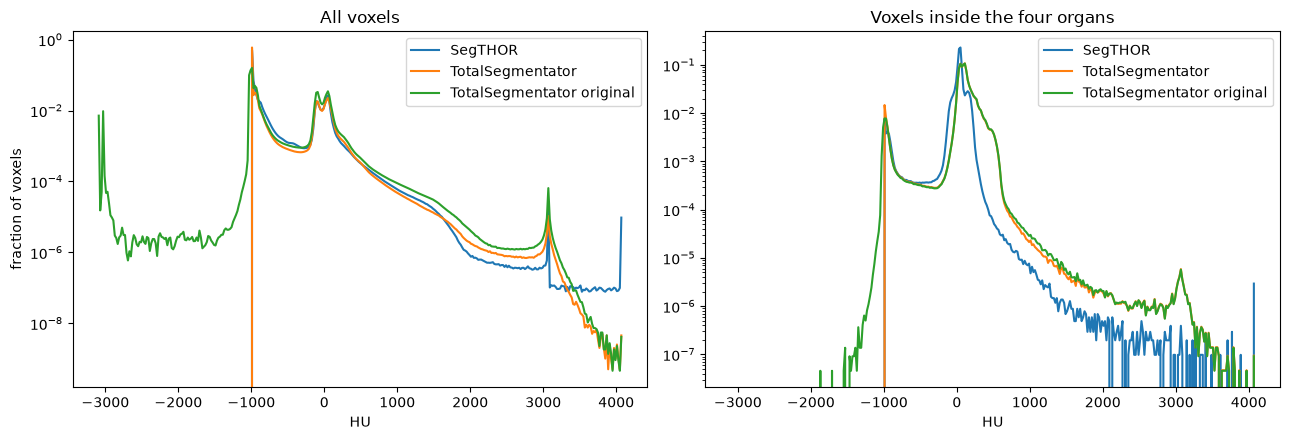

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, key, title in [(ax1, "hist", "All voxels"), (ax2, "hist_organs", "Voxels inside the four organs")]:
    for scans, name in DATASETS:
        counts = sum(s[key] for s in scans)
        line, = ax.plot(CENTERS, counts / counts.sum(), label=name)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("HU")
    ax.legend()

ax1.set_ylabel("fraction of voxels")
plt.tight_layout()
plt.show()

## Scanned area

To ensure that the scales between SegTHOR and TotalSegmentator are similar, we scale the TotalSegmentator to the same field of view as most SegTHOR patients. This causes those points to collapse onto the same line. Additionally the slices for the TotalSegmentator were cropped around the heart to only include regions relevant to thoric organs. This removes irrelevant slices such as lower body ones.

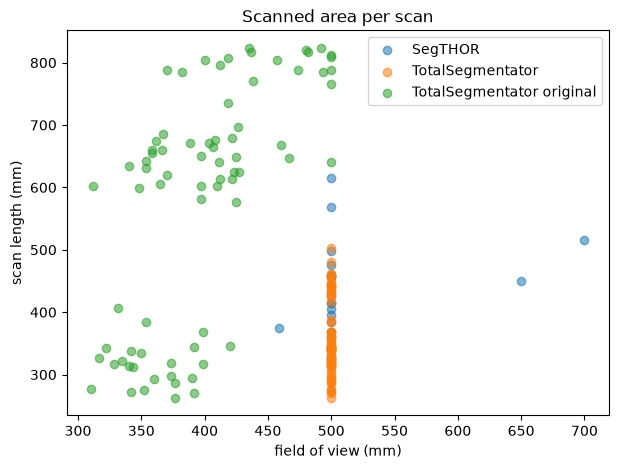

In [ ]:
plt.figure(figsize=(7, 5))
for scans, name in DATASETS:
    plt.scatter([s["fov_mm"] for s in scans], [s["length_mm"] for s in scans], alpha=ALPHA, label=name)

plt.xlabel("field of view (mm)")
plt.ylabel("scan length (mm)")
plt.title("Scanned area per scan")
plt.legend()
plt.show()

## Slices per scan
The original scans run up to 549 slices, most of them abdomen and pelvis. Cropping around the heart reduces this number to less than 350. What is left still contributes more slices per scan than
SegTHOR, because the slices are thinner (1.5 mm against 2-3.7 mm).

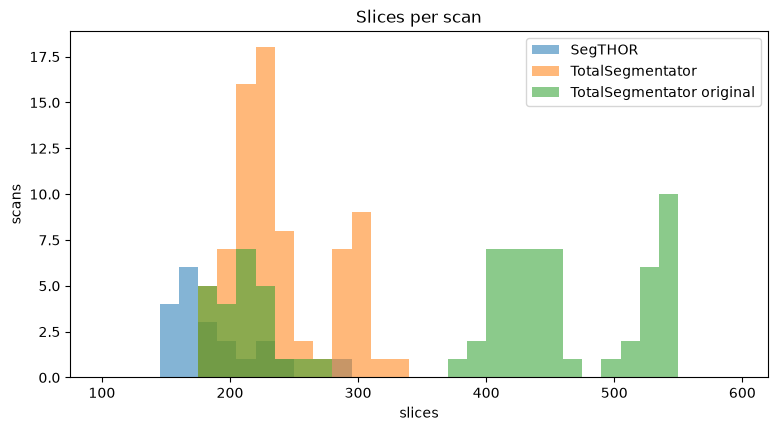

SegTHOR: 3732 slices in total
TotalSegmentator: 17857 slices in total
TotalSegmentator original: 28814 slices in total


In [ ]:
bins = np.arange(100, 600, 15)

plt.figure(figsize=(9, 4.5))
for scans, name in DATASETS:
    plt.hist([s["slices"] for s in scans], bins=bins, alpha=ALPHA, label=name)

plt.xlabel("slices")
plt.ylabel("scans")
plt.title("Slices per scan")
plt.legend()
plt.show()

for scans, name in DATASETS:
    print(f"{name}: {sum(s['slices'] for s in scans)} slices in total")

## Esophagus and aorta

The processed TotalSegmentator displays subtle differences compared to the original one caused due to the crop in slices. Caused by cases where the aorta segmentation annotation reached far under the heart.

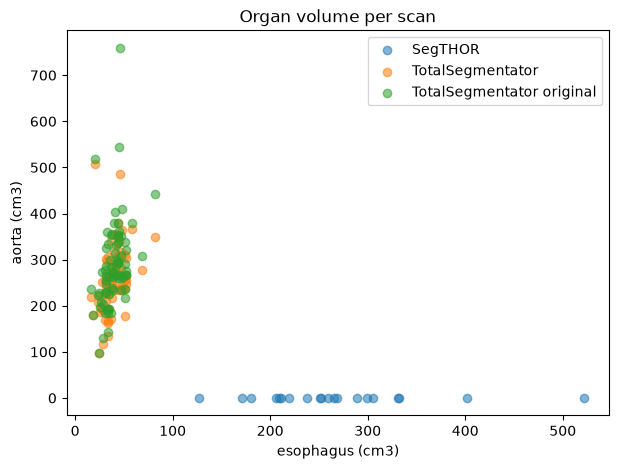

In [ ]:
plt.figure(figsize=(7, 5))
for scans, name in DATASETS:
    plt.scatter([s["volumes"]["esophagus"] for s in scans], [s["volumes"]["aorta"] for s in scans],
                alpha=ALPHA, label=name)

plt.xlabel("esophagus (cm3)")
plt.ylabel("aorta (cm3)")
plt.title("Organ volume per scan")
plt.legend()
plt.show()